# Create dataset

(200, 2) (200,)


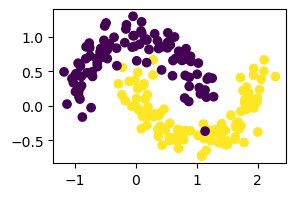

In [99]:
import numpy as np
import matplotlib.pyplot as plt
import sklearn.datasets

X,y = sklearn.datasets.make_moons(200, noise = 0.15)
print(X.shape, y.shape)

plt.figure(figsize=(3, 2))
plt.scatter(X[:,0], X[:,1], c=y)
plt.show()

In [100]:
print(y[0])
print(y.size)

0
200


# Define network

In [101]:
def retreive(model_dict):
    W1 = model_dict['W1']
    b1 = model_dict['b1']
    W2 = model_dict['W2']
    b2 = model_dict['b2']
    return W1, b1, W2, b2

def forward(X, model_dict):
    W1, b1, W2, b2 = retreive(model_dict)
    z1 = X.dot(W1) + b1 # (n,3)
    a1 = np.tanh(z1) # (n,3)
    z2 = a1.dot(W2) +b2 # z2: (n,2), W2: (3,2), b2: (3,2)
    exp_scores = np.exp(z2)
    softmax = exp_scores / np.sum(exp_scores, axis = 1, keepdims = True) # ~ y : (n,2)
    return  z1, a1, softmax 


def loss(softmax, y, model_dict):
    W1, b1, W2, b2 = retreive(model_dict)
    m = np.zeros(200)
    for i, correct_index in enumerate(y):
        predicted = softmax[i][correct_index]
        m[i] = predicted
        
    log_prob = -np.log(m)
    loss = np.sum(log_prob)
    reg_loss = lamda_reg / 2 * (np.sum(np.square(W1)) + np.sum(np.square(W2)))
    loss += reg_loss
    return float(loss/y.shape[0])

def predict(X, model_dict):
    W1, b1, W2, b2 = retreive(model_dict)
    z1 = X.dot(W1) + b1
    a1 = np.tanh(z1)
    z2 = a1.dot(W2) +b2
    exp_scores = np.exp(z2)
    softmax = exp_scores / np.sum(exp_scores, axis = 1, keepdims = True) # (200,2)
    return np.argmax(softmax, axis = 1) #(200,)


# Define backforward propagation

In [102]:
def backpropagation(X,y,model_dict, epochs):
    losses = []

    for i in range(epochs):
        W1, b1, W2, b2 = retreive(model_dict)
        z1, a1, probs = forward(X, model_dict) # (nx3), (nx3), (nx2)
        delta3 = np.copy(probs)
        delta3[range(X.shape[0]), y] -= 1
            
        dW2 = (a1.T).dot(delta3)
        db2 = np.sum(delta3, axis = 0, keepdims= True) # (1,2)

        delta2 = delta3.dot(W2.T) * (1-np.power(np.tanh(z1),2))
        dW1 = np.dot(X.T, delta2)
        db1 = np.sum(delta2, axis  = 0)

        # Regularization
        dW2 += lamda_reg * np.sum(W2)
        dW1 += lamda_reg * np.sum(W1)

        # Update weight
        W1 += -learning_rate * dW1
        b1 += -learning_rate * db1
        W2 += -learning_rate * dW2
        b2 += -learning_rate * db2

        model_dict = {'W1': W1, 'b1': b1, 'W2': W2, 'b2': b2}
        
        if i%50 == 0:
            l = loss(probs, y, model_dict)
            print("Loss at epoch {} is: {:.3f}".format(i, l))
            losses.append(l)

    
    return model_dict, losses

# Run and visualize the learning process

In [103]:
input_neurons = 2
output_neurons = 2
samples = X.shape[0]
learning_rate = 0.001
lamda_reg = 0.01 # Regularization

In [104]:
def init_net(input_dim, hidden_dim, output_dim):
    model = {}
    # He Norm Initialization
    W1 = np.random.randn(input_dim, hidden_dim) / np.sqrt(input_dim)
    b1 = np.zeros((1, hidden_dim))
    W2 = np.random.randn(hidden_dim, output_dim) / np.sqrt(hidden_dim)
    b2 = np.zeros((1, output_dim))
    model['W1'] = W1
    model['b1'] = b1
    model['W2'] = W2
    model['b2'] = b2
    return model

model_dict = init_net(input_dim = input_neurons , hidden_dim = 3, output_dim = output_neurons)
model, loss1 = backpropagation(X, y, model_dict, 1000)


Loss at epoch 0 is: 0.771
Loss at epoch 50 is: 0.304
Loss at epoch 100 is: 0.280
Loss at epoch 150 is: 0.275
Loss at epoch 200 is: 0.272
Loss at epoch 250 is: 0.268
Loss at epoch 300 is: 0.263
Loss at epoch 350 is: 0.255
Loss at epoch 400 is: 0.245
Loss at epoch 450 is: 0.234
Loss at epoch 500 is: 0.221
Loss at epoch 550 is: 0.209
Loss at epoch 600 is: 0.197
Loss at epoch 650 is: 0.186
Loss at epoch 700 is: 0.176
Loss at epoch 750 is: 0.166
Loss at epoch 800 is: 0.157
Loss at epoch 850 is: 0.148
Loss at epoch 900 is: 0.140
Loss at epoch 950 is: 0.132


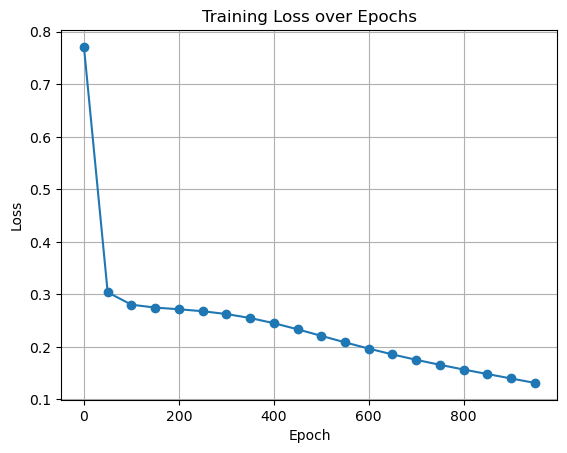

In [105]:
import matplotlib.pyplot as plt

epochs = [i * 50 for i in range(len(loss1))]  # tạo danh sách epoch tương ứng

# Vẽ biểu đồ
plt.plot(epochs, loss1, marker='o')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss over Epochs")
plt.grid(True)
plt.show()


